# LSTM: Trajectory Regression + 3‑Klassen‑Wurfklassifikation
Dieses Notebook implementiert **genau die gewünschte Aufteilung**:
- **Modus A (noisy)**  (vollständige Sequenz → vollständige Sequenz)
- **Modus B (clean-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste cleanen 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)
- **Modus C (noisy-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste noisy 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)

Es erzeugt synthetische Ballistik‑Trajektorien, baut **Train/Validation/Test**‑Splits, trainiert die Modelle und evaluiert Regression & Klassifikation.


In [37]:

# 0) Imports & Setup
import os, random
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Daten laden

In [38]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
df["point_index"] = df.groupby("wurf_id").cumcount()
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 13)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0', 'point_index']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0,point_index
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672,0
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672,1
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672,2
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672,3
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672,4


In [39]:
# Pro Wurf aggregieren
per_throw = (
    df.groupby("wurf_id")
    .agg({"label": "first", "theta": "first", "v0": "first", "T": "first"})
    .reset_index()
)

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


In [40]:
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

df_train = (
    df[df["wurf_id"].isin(train_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_val = (
    df[df["wurf_id"].isin(val_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_test = (
    df[df["wurf_id"].isin(test_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Scaling (fit auf Train)

In [41]:

class XYScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, xy: np.ndarray):
        self.mean_ = xy.mean(axis=0, keepdims=True)
        self.std_ = xy.std(axis=0, keepdims=True) + 1e-8
        return self

    def transform(self, xy: np.ndarray) -> np.ndarray:
        return (xy - self.mean_) / self.std_

    def inverse_transform(self, xy_scaled: np.ndarray) -> np.ndarray:
        return xy_scaled * self.std_ + self.mean_

# Fit auf clean targets aus Train
train_xy = df_train[["x_clean","y_clean"]].to_numpy(np.float32)
scaler = XYScaler().fit(train_xy)

# Quick sanity: Standardisierung
xy_s = scaler.transform(train_xy)
xy_s.mean(axis=0), xy_s.std(axis=0)


(array([ 2.9947156e-08, -5.0125834e-07], dtype=float32),
 array([1.        , 0.99999994], dtype=float32))

## 4) Dataset

In [42]:
def df_to_wurf_arrays(df: pd.DataFrame):
    # group each wurf into arrays ordered by point_index
    groups = []
    for wid, g in df.groupby("wurf_id"):
        g = g.sort_values("point_index")
        groups.append(g)
    return groups


class ExtrapolationDataset(Dataset):
    """Für ExtrapSeq2SeqModel (Option 2): observed Tin → **vollständig vorhergesagte** Trajektorie (T).

    - Encoder sieht die ersten Tin Punkte (x,y,t_norm).
    - Decoder erzeugt **alle** T Punkte autoregressiv.
    - Targets (y_all) enthalten die komplette Trajektorie (T,2).
    """
    def __init__(self, df, scaler, tin, input_source="clean", target_source="clean"):
        self.df = df
        self.scaler = scaler
        self.tin = tin
        self.input_source = input_source
        self.target_source = target_source

        # >>> neu: wurf_id-Liste + Gruppen, damit wir für idx wieder an die Rohdaten kommen
        self.throw_ids = list(self.df["wurf_id"].unique())
        self.groups = {k: g.sort_values("point_index").reset_index(drop=True)
                       for k, g in self.df.groupby("wurf_id")}

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        wid = self.throw_ids[idx]
        g = self.groups[wid]
        label = int(g["label"].iloc[0])

        T = len(g)
        assert self.tin <= T

        # --- NEW: time normalization without future knowledge ---
        t = g["t"].to_numpy(np.float32)[:, None]        # (T,1) absolute time (seconds)
        t_min = float(t[0, 0])                          # or: float(t.min()) if you prefer
        t_obs_max = float(t[self.tin - 1, 0])           # last observed time

        denom = max(1e-8, (t_obs_max - t_min))          # guard against tin==1 or degenerate
        t_n = (t - t_min) / denom                       # observed in [0,1], future > 1
        # -------------------------------------------------------

        xy_clean = g[["x_clean","y_clean"]].to_numpy(np.float32)
        xy_noisy = g[["x_noisy","y_noisy"]].to_numpy(np.float32)

        xy_in  = xy_noisy if self.input_source=="noisy" else xy_clean
        xy_tgt = xy_clean if self.target_source=="clean" else xy_noisy

        xy_in_s  = self.scaler.transform(xy_in)    # (T,2)
        xy_tgt_s = self.scaler.transform(xy_tgt)   # (T,2)

        # Encoder input: (Tin,3) = [x,y,t_norm]
        x_in = np.concatenate([xy_in_s[:self.tin], t_n[:self.tin]], axis=1).astype(np.float32)

        # Decoder times for *all* steps: (T,1)
        t_all = t_n.astype(np.float32)

        # Full targets: (T,2)
        y_all = xy_tgt_s.astype(np.float32)

        return (
            torch.from_numpy(x_in),                 # (Tin,3)
            torch.from_numpy(t_all),                # (T,1)
            torch.from_numpy(y_all),                # (T,2)
            torch.tensor(label, dtype=torch.long)
        )


def collate_extrap(batch):
    # Pads are not needed: Tin and T are fixed by construction.
    x_in, t_all, y_all, labels = zip(*batch)
    return (
        torch.stack(x_in, dim=0),     # (B,Tin,3)
        torch.stack(t_all, dim=0),    # (B,T,1)
        torch.stack(y_all, dim=0),    # (B,T,2)
        torch.stack(labels, dim=0),   # (B,)
    )

## 5) Modelle

In [43]:
class ExtrapSeq2SeqModel(nn.Module):
    """
    Option 2 (vollständig predicted):
    - Encoder sieht beobachtete Punkte (x,y,t_norm) der Länge Tin.
    - Decoder läuft autoregressiv über **alle** T Zeitschritte und erzeugt (x,y).
      Decoder-Input pro Schritt: [prev_x, prev_y, t_k] (3 Werte).

    Teacher forcing (Training): prev_xy = y_all[:,k] (Ground Truth des aktuellen Schritts)
    Autoregressiv (Eval): prev_xy = xy_k (eigene Vorhersage)
    """

    def __init__(self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
        )
        self.dec_cell = nn.LSTMCell(input_size=3, hidden_size=hidden_dim)
        self.out_head = nn.Linear(hidden_dim, 2)
        self.cls_head = nn.Linear(hidden_dim, n_classes)

        # Learnable start token for the decoder (scaled xy)
        self.start_xy = nn.Parameter(torch.zeros(2))

    def forward(self, x_in, t_all, y_all=None, teacher_forcing=True):
        """
        x_in:  (B,Tin,3) = [x,y,t_norm] (observed)
        t_all: (B,T,1)   = all normalized times
        y_all: (B,T,2)   = full ground truth (optional, for teacher forcing)

        returns:
          y_hat:  (B,T,2)  full predicted trajectory (scaled)
          logits: (B,3)
        """
        out, (hN, cN) = self.enc(x_in)      # out: (B,Tin,H)
        h = hN[-1]                           # (B,H)
        c = cN[-1]

        logits = self.cls_head(h)           # (B,3)

        B = x_in.size(0)
        T = t_all.size(1)

        preds = []
        prev_xy = self.start_xy.unsqueeze(0).expand(B, -1)  # (B,2)

        for k in range(T):
            dec_in = torch.cat([prev_xy, t_all[:, k, :]], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            xy_k = self.out_head(h)                               # (B,2)
            preds.append(xy_k.unsqueeze(1))

            if teacher_forcing and (y_all is not None):
                prev_xy = y_all[:, k, :]
            else:
                prev_xy = xy_k

        y_hat = torch.cat(preds, dim=1)  # (B,T,2)
        return y_hat, logits

## 6) Training & Evaluation Helpers

In [44]:
def mse_loss(pred, target):
    return F.mse_loss(pred, target)

def train_extrap(
    model: ExtrapSeq2SeqModel,
    train_loader: DataLoader,
    val_loader: DataLoader,
    tin: int = 30,
    epochs: int = 25,
    lr: float = 2e-3,
    cls_weight: float = 0.2,
    teacher_forcing: bool = True,
    verbose: bool = True,
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    best = {"loss": 1e18, "state": None}
    hist = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": [], "tr_mse_future": [], "va_mse_future": []}

    for ep in range(1, epochs + 1):
        # Train
        model.train()
        tr_losses, tr_y, tr_p, tr_mse_f = [], [], [], []
        for x_in, t_all, y_all, c in train_loader:
            x_in = x_in.to(device)
            t_all = t_all.to(device)
            y_all = y_all.to(device)
            c = c.to(device)

            yhat, logits = model(x_in, t_all, y_all=y_all, teacher_forcing=teacher_forcing)

            T = y_all.size(1)

            if tin >= T:
                future_mse = 0.0
            else:
                future_mse = F.mse_loss(yhat[:, tin:, :], y_all[:, tin:, :]).item()

            loss_reg = F.mse_loss(yhat, y_all)
            loss_cls = F.cross_entropy(logits, c)
            loss = loss_reg + cls_weight * loss_cls

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_losses.append(loss.item())
            # Future-only mse (reporting)
            tr_mse_f.append(future_mse)

            tr_y.extend(c.detach().cpu().tolist())
            tr_p.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

        tr_acc = accuracy_score(tr_y, tr_p)

        # Val (autoregressiv)
        model.eval()
        va_losses, va_y, va_p, va_mse_f = [], [], [], []
        with torch.no_grad():
            for x_in, t_all, y_all, c in val_loader:
                x_in = x_in.to(device)
                t_all = t_all.to(device)
                y_all = y_all.to(device)
                c = c.to(device)

                yhat, logits = model(x_in, t_all, y_all=None, teacher_forcing=False)

                T = y_all.size(1)

                if tin >= T:
                    future_mse = 0.0
                else:
                    future_mse = F.mse_loss(yhat[:, tin:, :], y_all[:, tin:, :]).item()

                va_mse_f.append(future_mse)

                loss_reg = F.mse_loss(yhat, y_all)
                loss_cls = F.cross_entropy(logits, c)
                loss = loss_reg + cls_weight * loss_cls

                va_losses.append(loss.item())

                va_y.extend(c.cpu().tolist())
                va_p.extend(torch.argmax(logits, dim=1).cpu().tolist())

        va_acc = accuracy_score(va_y, va_p)

        tr_loss = float(np.mean(tr_losses))
        va_loss = float(np.mean(va_losses))

        hist["tr_loss"].append(tr_loss)
        hist["va_loss"].append(va_loss)
        hist["tr_acc"].append(tr_acc)
        hist["va_acc"].append(va_acc)
        hist["tr_mse_future"].append(float(np.mean(tr_mse_f)))
        hist["va_mse_future"].append(float(np.mean(va_mse_f)))

        if va_loss < best["loss"]:
            best["loss"] = va_loss
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[C] ep={ep:02d} tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} "
                f"| tr_acc={tr_acc:.3f} va_acc={va_acc:.3f} "
                f"| va_future_mse={hist['va_mse_future'][-1]:.5f}"
            )

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return hist


def eval_extrap(model: ExtrapSeq2SeqModel, loader: DataLoader, tin: int = 30, split_name="test"):
    model.eval()
    all_y, all_p = [], []
    mse_full, mse_future = [], []
    with torch.no_grad():
        for x_in, t_all, y_all, c in loader:
            x_in = x_in.to(device)
            t_all = t_all.to(device)
            y_all = y_all.to(device)
            c = c.to(device)

            yhat, logits = model(x_in, t_all, y_all=None, teacher_forcing=False)

            mse_full.append(F.mse_loss(yhat, y_all).item())

            T = y_all.size(1)
            if tin >= T:
                mse_f = 0.0
            else:
                mse_f = F.mse_loss(yhat[:, tin:, :], y_all[:, tin:, :]).item()
            mse_future.append(mse_f)


            all_y.extend(c.cpu().tolist())
            all_p.extend(torch.argmax(logits, dim=1).cpu().tolist())

    acc = accuracy_score(all_y, all_p)
    cm = confusion_matrix(all_y, all_p, labels=[0,1,2])

    print(f"[{split_name}] full_mse_scaled={float(np.mean(mse_full)):.5f} | future_mse_scaled={float(np.mean(mse_future)):.5f} | acc={acc:.3f}")
    print(classification_report(all_y, all_p, digits=3))

    return cm


def plot_cm(cm, title="Confusion Matrix"):
    fig = plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0,1,2])
    plt.yticks([0,1,2])
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.show()


def plot_history(hist: dict, title: str):

    def _plot(keys, subtitle):
        present = [k for k in keys if k in hist and len(hist[k]) > 0]
        if not present:
            return
        plt.figure(figsize=(10, 4))
        for k in present:
            plt.plot(hist[k], label=k)
        plt.title(subtitle)
        plt.xlabel("epoch")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

    # loss
    _plot(["train_loss", "val_loss", "tr_loss", "va_loss"], title)

    # accuracy
    _plot(["train_acc", "val_acc", "tr_acc", "va_acc"], title + " (accuracy)")

    # future MSE (falls vorhanden)
    _plot(
        ["train_mse_future", "val_mse_future", "tr_mse_future", "va_mse_future"],
        title + " (future MSE)",
    )

## 7) Modus A (noisy) mit  ExtrapSeq2SeqModel
Encoder bekommt **Tin=50** noisy Punkte

[C] ep=01 tr_loss=1.2459 va_loss=1.2398 | tr_acc=0.336 va_acc=0.350 | va_future_mse=0.00000
[C] ep=02 tr_loss=1.1227 va_loss=1.1910 | tr_acc=0.336 va_acc=0.350 | va_future_mse=0.00000
[C] ep=03 tr_loss=0.9999 va_loss=1.0617 | tr_acc=0.336 va_acc=0.350 | va_future_mse=0.00000
[C] ep=04 tr_loss=0.7802 va_loss=0.7514 | tr_acc=0.336 va_acc=0.350 | va_future_mse=0.00000
[C] ep=05 tr_loss=0.5366 va_loss=0.6945 | tr_acc=0.271 va_acc=0.400 | va_future_mse=0.00000
[C] ep=06 tr_loss=0.5242 va_loss=0.7304 | tr_acc=0.439 va_acc=0.450 | va_future_mse=0.00000
[C] ep=07 tr_loss=0.4578 va_loss=0.4905 | tr_acc=0.411 va_acc=0.300 | va_future_mse=0.00000
[C] ep=08 tr_loss=0.3375 va_loss=0.4312 | tr_acc=0.402 va_acc=0.500 | va_future_mse=0.00000
[C] ep=09 tr_loss=0.3190 va_loss=0.4446 | tr_acc=0.486 va_acc=0.500 | va_future_mse=0.00000
[C] ep=10 tr_loss=0.2954 va_loss=0.5182 | tr_acc=0.551 va_acc=0.500 | va_future_mse=0.00000
[C] ep=11 tr_loss=0.3029 va_loss=0.3934 | tr_acc=0.542 va_acc=0.550 | va_future_

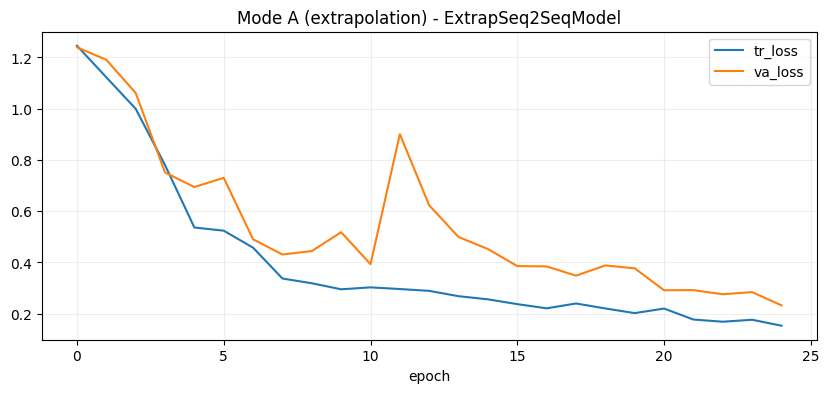

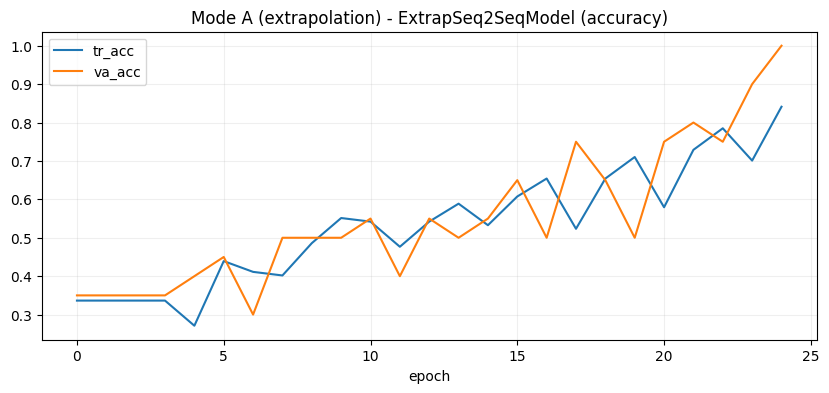

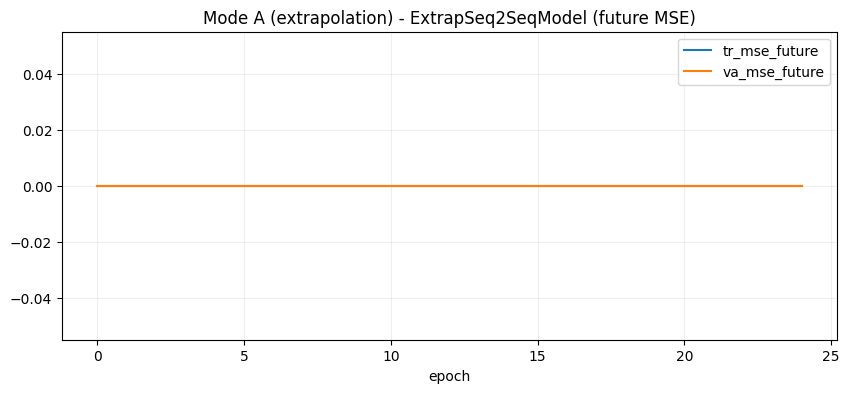

[test A] full_mse_scaled=0.18092 | future_mse_scaled=0.00000 | acc=0.957
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         8
           1      1.000     0.875     0.933         8
           2      0.875     1.000     0.933         7

    accuracy                          0.957        23
   macro avg      0.958     0.958     0.956        23
weighted avg      0.962     0.957     0.957        23



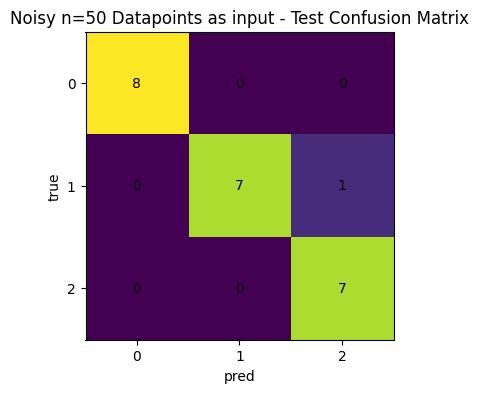

In [45]:
batch_size = 64

tin = 50

df_train = df[df["wurf_id"].isin(train_ids)].reset_index(drop=True)
df_val   = df[df["wurf_id"].isin(val_ids)].reset_index(drop=True)
df_test  = df[df["wurf_id"].isin(test_ids)].reset_index(drop=True)

dsA_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlA_train = DataLoader(dsA_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlA_val   = DataLoader(dsA_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlA_test  = DataLoader(dsA_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelA = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histA = train_extrap(
    modelA, dlA_train, dlA_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    teacher_forcing=True
)

plot_history(histA, "Mode A (extrapolation) - ExtrapSeq2SeqModel")

cmA = eval_extrap(modelA, dlA_test, tin=tin, split_name="test A")
plot_cm(cmA, "Noisy n=50 Datapoints as input - Test Confusion Matrix")

## 8) Modus B (clean-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

[C] ep=01 tr_loss=1.1799 va_loss=1.2218 | tr_acc=0.336 va_acc=0.350 | va_future_mse=0.89650
[C] ep=02 tr_loss=1.0645 va_loss=1.1727 | tr_acc=0.486 va_acc=0.500 | va_future_mse=0.84797
[C] ep=03 tr_loss=0.9299 va_loss=1.0507 | tr_acc=0.477 va_acc=0.500 | va_future_mse=0.75349
[C] ep=04 tr_loss=0.7163 va_loss=0.7437 | tr_acc=0.383 va_acc=0.400 | va_future_mse=0.54220
[C] ep=05 tr_loss=0.4425 va_loss=0.4985 | tr_acc=0.439 va_acc=0.450 | va_future_mse=0.35639
[C] ep=06 tr_loss=0.3479 va_loss=0.7262 | tr_acc=0.467 va_acc=0.500 | va_future_mse=0.56444
[C] ep=07 tr_loss=0.3168 va_loss=0.8438 | tr_acc=0.514 va_acc=0.500 | va_future_mse=1.20485
[C] ep=08 tr_loss=0.2809 va_loss=0.5099 | tr_acc=0.430 va_acc=0.400 | va_future_mse=0.45817
[C] ep=09 tr_loss=0.2726 va_loss=0.6748 | tr_acc=0.439 va_acc=0.400 | va_future_mse=0.70771
[C] ep=10 tr_loss=0.2809 va_loss=0.6180 | tr_acc=0.402 va_acc=0.550 | va_future_mse=0.60408
[C] ep=11 tr_loss=0.2677 va_loss=0.5097 | tr_acc=0.467 va_acc=0.500 | va_future_

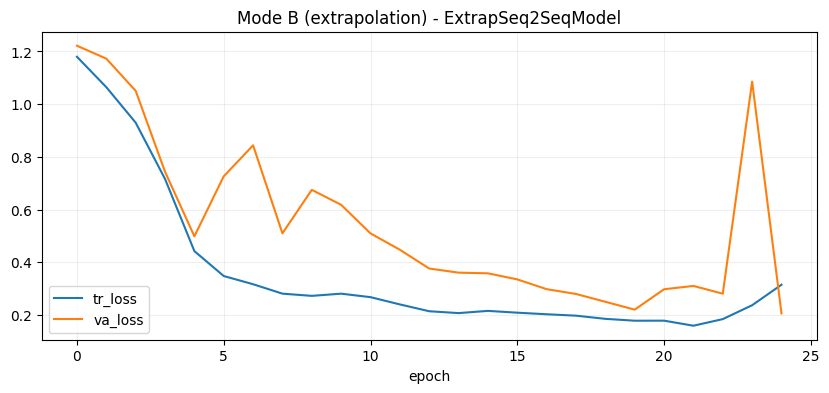

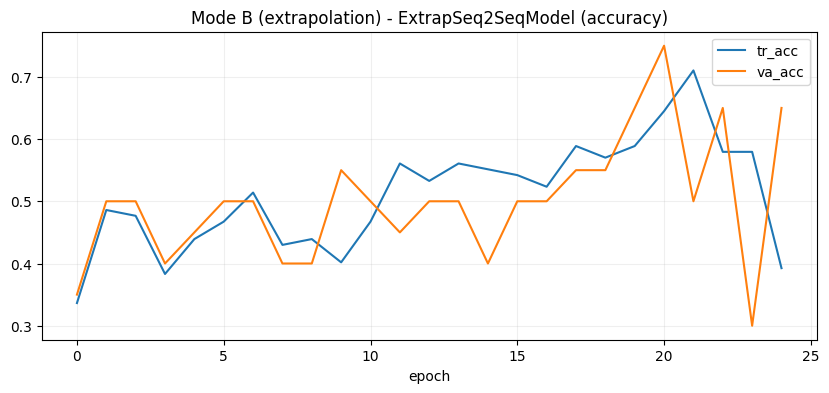

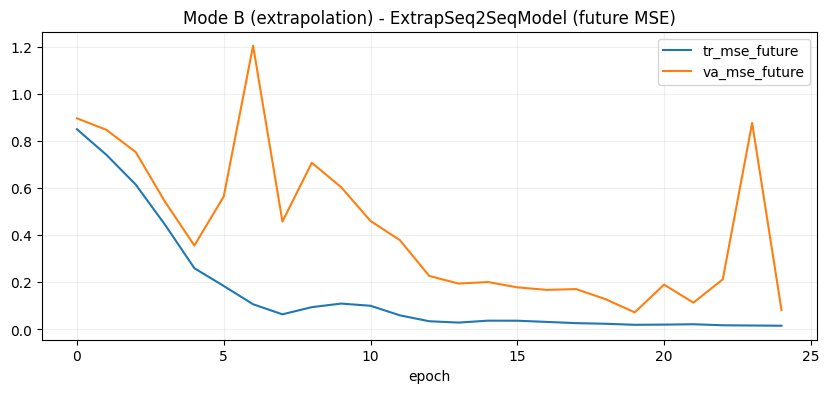

[test B] full_mse_scaled=0.07234 | future_mse_scaled=0.06994 | acc=0.652
              precision    recall  f1-score   support

           0      1.000     0.875     0.933         8
           1      0.500     0.250     0.333         8
           2      0.500     0.857     0.632         7

    accuracy                          0.652        23
   macro avg      0.667     0.661     0.633        23
weighted avg      0.674     0.652     0.633        23



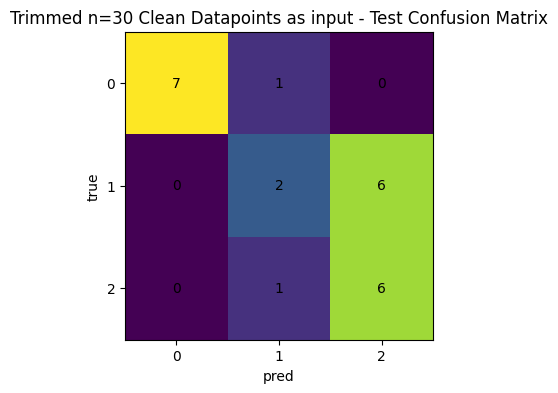

In [46]:
tin = 30
dsB_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlB_train = DataLoader(dsB_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlB_val   = DataLoader(dsB_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlB_test  = DataLoader(dsB_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelB = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histB = train_extrap(
    modelB, dlB_train, dlB_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    teacher_forcing=True
)

plot_history(histB, "Mode B (extrapolation) - ExtrapSeq2SeqModel")

cmB = eval_extrap(modelB, dlB_test, tin=tin, split_name="test B")
plot_cm(cmB, "Trimmed n=30 Clean Datapoints as input - Test Confusion Matrix")

## 9) Modus C (noisy-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** noisy Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

[C] ep=01 tr_loss=1.2257 va_loss=1.2346 | tr_acc=0.346 va_acc=0.450 | va_future_mse=0.85299
[C] ep=02 tr_loss=1.1050 va_loss=1.1811 | tr_acc=0.523 va_acc=0.450 | va_future_mse=0.80856
[C] ep=03 tr_loss=0.9586 va_loss=1.0271 | tr_acc=0.477 va_acc=0.450 | va_future_mse=0.72425
[C] ep=04 tr_loss=0.7234 va_loss=0.7208 | tr_acc=0.458 va_acc=0.400 | va_future_mse=0.60324
[C] ep=05 tr_loss=0.5231 va_loss=0.9608 | tr_acc=0.477 va_acc=0.350 | va_future_mse=0.69739
[C] ep=06 tr_loss=0.4925 va_loss=0.5941 | tr_acc=0.477 va_acc=0.350 | va_future_mse=0.33199
[C] ep=07 tr_loss=0.4004 va_loss=0.5806 | tr_acc=0.374 va_acc=0.450 | va_future_mse=0.47316
[C] ep=08 tr_loss=0.3255 va_loss=0.4747 | tr_acc=0.514 va_acc=0.450 | va_future_mse=0.30226
[C] ep=09 tr_loss=0.3125 va_loss=0.8659 | tr_acc=0.486 va_acc=0.500 | va_future_mse=1.29324
[C] ep=10 tr_loss=0.3024 va_loss=0.4185 | tr_acc=0.477 va_acc=0.450 | va_future_mse=0.25328
[C] ep=11 tr_loss=0.2855 va_loss=0.4215 | tr_acc=0.542 va_acc=0.450 | va_future_

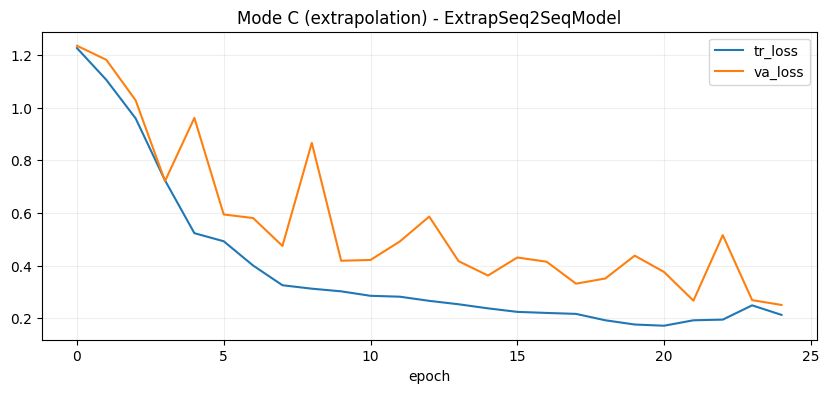

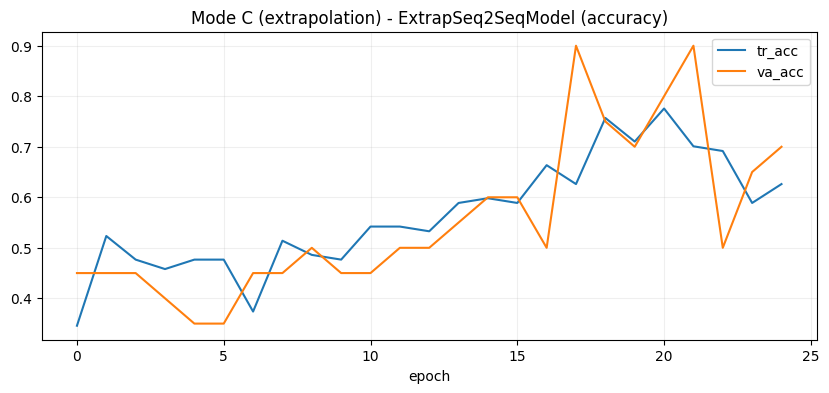

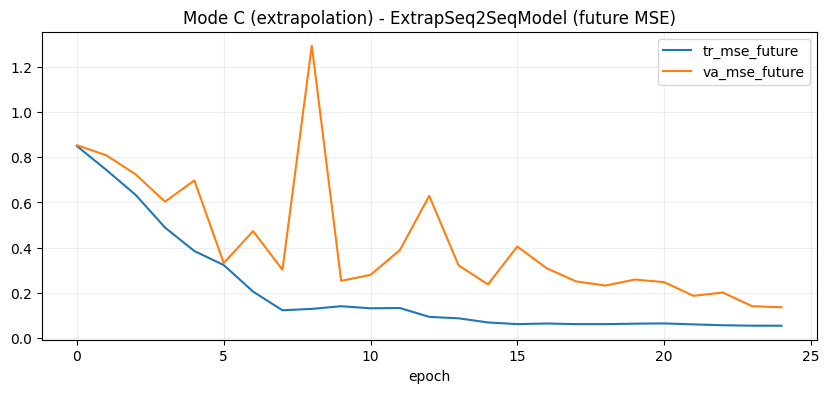

[test C] full_mse_scaled=0.15217 | future_mse_scaled=0.18101 | acc=0.522
              precision    recall  f1-score   support

           0      1.000     0.750     0.857         8
           1      0.333     0.375     0.353         8
           2      0.375     0.429     0.400         7

    accuracy                          0.522        23
   macro avg      0.569     0.518     0.537        23
weighted avg      0.578     0.522     0.543        23



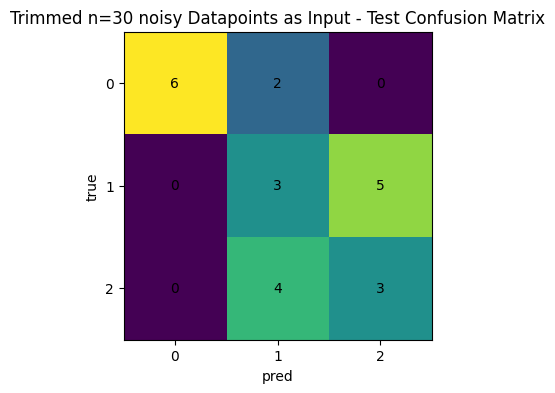

In [47]:
tin = 30
dsC_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlC_train = DataLoader(dsC_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlC_val   = DataLoader(dsC_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlC_test  = DataLoader(dsC_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelC = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histC = train_extrap(
    modelC, dlC_train, dlC_val,
    tin=tin,
    epochs=25, lr=2e-3, cls_weight=0.2,
    teacher_forcing=True
)

plot_history(histC, "Mode C (extrapolation) - ExtrapSeq2SeqModel")

cmC = eval_extrap(modelC, dlC_test, tin=tin, split_name="test C")
plot_cm(cmC, "Trimmed n=30 noisy Datapoints as Input - Test Confusion Matrix")

## 10) Qualitative Plots: Trajektorien (Ground Truth vs Prediction)
Wir plotten pro Modus ein Beispiel aus Test.

Wurf 89 | true label=2 | pred label=2
Tin=50 | obs=noisy | GT=clean


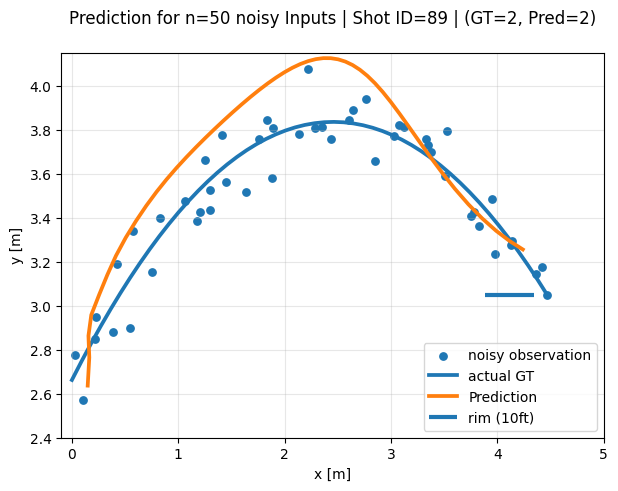

Wurf 1 | true label=1 | pred label=1
Tin=30 | input=clean | target(GT)=clean | denom=0.576648


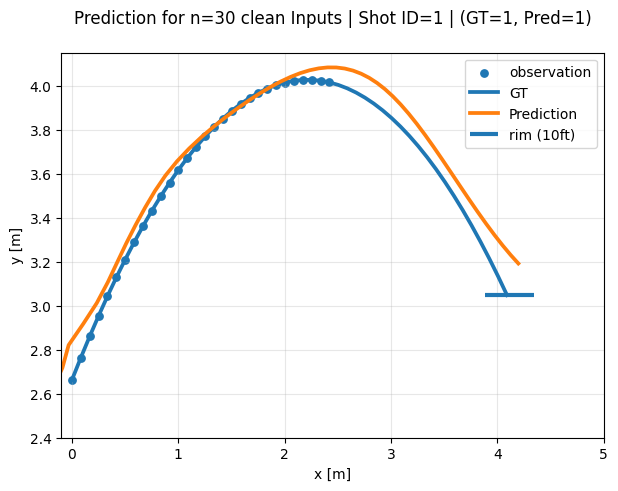

Wurf 71 | true label=2 | pred label=1
Tin=30 | obs=noisy | GT=clean


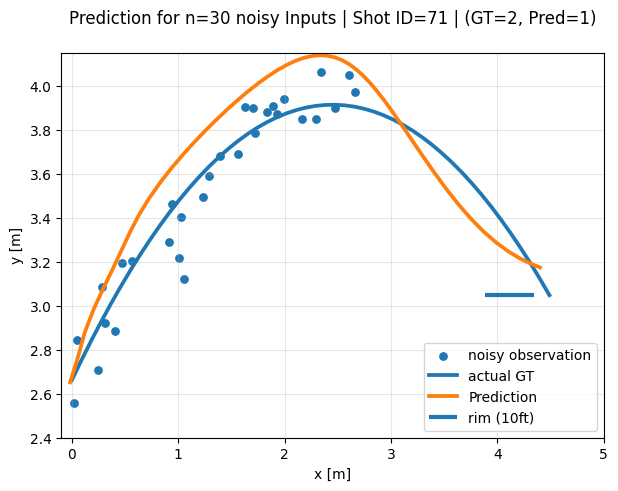

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# --- helper: time normalization exactly like in ExtrapolationDataset ---
def normalize_time_np(t_abs: np.ndarray, t_min: float, denom: float) -> np.ndarray:
    # t_abs: (T,1) float32
    denom = max(1e-8, float(denom))
    return (t_abs - float(t_min)) / denom


def _get_globals_or_raise(model, scaler, device, dg):
    if model is None:
        model = globals().get("model", None)
    if scaler is None:
        scaler = globals().get("scaler", None)
    if device is None:
        device = globals().get("device", None)
    if dg is None:
        dg = globals().get("dg", None)

    missing = [
        name
        for name, obj in [("model", model), ("scaler", scaler), ("device", device)]
        if obj is None
    ]
    if missing:
        raise RuntimeError(
            f"Fehlt im Scope: {missing}. Übergib sie als Parameter oder setze globale Variablen."
        )
    return model, scaler, device, dg


def _build_from_ds_groups(
    ds,
    scaler,
    idx: int,
    n_obs: int | None = None,
    input_source: str | None = None,
    target_source: str | None = None,
):
    """
    Baut alle Arrays/Tensors wie im Dataset, aber erlaubt n_obs override.
    Gibt zusätzlich unskalierte XYs in Metern fürs Plotten zurück.
    """
    wid = ds.throw_ids[idx]
    g = ds.groups[wid]

    T = len(g)
    Tin = int(n_obs) if n_obs is not None else int(ds.tin)
    assert 1 <= Tin <= T, f"Tin/n_obs={Tin} ist ungültig für T={T}"

    in_src = input_source if input_source is not None else ds.input_source
    tg_src = target_source if target_source is not None else ds.target_source

    # raw (meters)
    t_abs = g["t"].to_numpy(np.float32)[:, None]  # (T,1)
    xy_clean = g[["x_clean", "y_clean"]].to_numpy(np.float32)  # (T,2)
    xy_noisy = g[["x_noisy", "y_noisy"]].to_numpy(np.float32)  # (T,2)

    xy_in_m = xy_noisy if in_src == "noisy" else xy_clean  # for plotting obs
    xy_gt_m = xy_clean if tg_src == "clean" else xy_noisy  # for plotting GT

    # time norm (no future knowledge): denom based on last observed time
    t_min = float(t_abs[0, 0])
    t_obs_max = float(t_abs[Tin - 1, 0])
    denom = max(1e-8, (t_obs_max - t_min))
    t_n = normalize_time_np(t_abs, t_min, denom).astype(np.float32)  # (T,1)

    # scale XY like training
    xy_in_s = scaler.transform(xy_in_m)  # (T,2)
    xy_gt_s = scaler.transform(xy_gt_m)  # (T,2)

    # model tensors (match ExtrapolationDataset)
    x_in = np.concatenate([xy_in_s[:Tin], t_n[:Tin]], axis=1).astype(
        np.float32
    )  # (Tin,3)
    t_all = t_n.astype(np.float32)  # (T,1)
    y_all = xy_gt_s.astype(np.float32)  # (T,2)

    label = int(g["label"].iloc[0])

    return {
        "wurf_id": wid,
        "label": label,
        "Tin": Tin,
        "T": T,
        "t_min": t_min,
        "denom": float(denom),
        "xy_obs_m": xy_in_m[:Tin],  # (Tin,2) meters
        "xy_gt_m": xy_gt_m,  # (T,2) meters
        "x_in": torch.from_numpy(x_in),  # (Tin,3)
        "t_all": torch.from_numpy(t_all),  # (T,1)
        "y_all": torch.from_numpy(y_all),  # (T,2)
        "input_source": in_src,
        "target_source": tg_src,
    }


@torch.no_grad()
def demo_reconstruction(
    ds,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
):
    """
    Plot wie in deinem Beispiel:
      - scatter: observation (erste Tin Punkte)
      - line: GT (full)
      - line: prediction (full)
      - rim line
    """
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    s = _build_from_ds_groups(ds, scaler, idx=idx, n_obs=n_obs)
    wid = s["wurf_id"]

    model.eval()
    y_hat, logits = model(
        s["x_in"].unsqueeze(0).to(device),
        s["t_all"].unsqueeze(0).to(device),
        y_all=None,
        teacher_forcing=False,
    )

    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(s["label"])

    # inverse scale predictions to meters
    y_hat_m = scaler.inverse_transform(y_hat.squeeze(0).cpu().numpy())  # (T,2)

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(
        f"Tin={s['Tin']} | input={s['input_source']} | target(GT)={s['target_source']} | denom={s['denom']:.6f}"
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(s["xy_obs_m"][:, 0], s["xy_obs_m"][:, 1], s=28, label="observation")
    plt.plot(s["xy_gt_m"][:, 0], s["xy_gt_m"][:, 1], linewidth=2.7, label="GT")
    plt.plot(y_hat_m[:, 0], y_hat_m[:, 1], linewidth=2.7, label="Prediction")
    plt.hlines(
        y=3.048,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )

    plt.title(
        f"Prediction for n={s['Tin']} {s['input_source']} Inputs | "
        f"Shot ID={wid} | (GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(
    ds_noisy,
    ds_clean,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
):
    """
    Wie dein noisy-vs-clean Beispiel:
      - obs: noisy (Tin)
      - GT: clean (full)
      - prediction: aus noisy-Input (Modeloutput wird wie üblich inverse-skaliert geplottet)
    Wichtig: ds_noisy und ds_clean müssen die gleichen wurf_ids im Split enthalten.
    """
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    # sample from noisy ds
    sN = _build_from_ds_groups(
        ds_noisy,
        scaler,
        idx=idx,
        n_obs=n_obs,
        input_source="noisy",
        target_source=ds_noisy.target_source,
    )
    wid = sN["wurf_id"]

    # build index cache for ds_clean by wurf_id
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {ds_clean.throw_ids[j]: j for j in range(len(ds_clean))}
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wid not in clean_index:
        raise KeyError(f"wurf_id={wid} nicht im ds_clean gefunden. Prüfe Split/IDs.")
    sC = _build_from_ds_groups(
        ds_clean,
        scaler,
        idx=clean_index[wid],
        n_obs=sN["Tin"],
        input_source=ds_clean.input_source,
        target_source="clean",
    )

    model.eval()
    y_hat, logits = model(
        sN["x_in"].unsqueeze(0).to(device),
        sN["t_all"].unsqueeze(0).to(device),
        y_all=None,
        teacher_forcing=False,
    )

    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(sN["label"])

    y_hat_m = scaler.inverse_transform(y_hat.squeeze(0).cpu().numpy())

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(f"Tin={sN['Tin']} | obs=noisy | GT=clean")

    plt.figure(figsize=(7, 5))
    plt.scatter(
        sN["xy_obs_m"][:, 0], sN["xy_obs_m"][:, 1], s=28, label="noisy observation"
    )
    plt.plot(
        sC["xy_gt_m"][:, 0],
        sC["xy_gt_m"][:, 1],
        linewidth=2.7,
        label="actual GT",
    )
    plt.plot(y_hat_m[:, 0], y_hat_m[:, 1], linewidth=2.7, label="Prediction")
    plt.hlines(
        y=3.048,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )
    plt.title(
        f"Prediction for n={sN['Tin']} noisy Inputs | "
        f"Shot ID={wid} | "
        f"(GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()

demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsA_test,
    ds_clean=dsA_clean_test,
    idx=14,
    n_obs=50,
    model=modelA,
    scaler=scaler,
    device=device,
)

demo_reconstruction(
    ds=dsB_test,
    idx=0,
    n_obs=30,
    model=modelB,
    scaler=scaler,
    device=device,
)

demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsC_test,
    ds_clean=dsA_clean_test,
    idx=11,
    n_obs=30,
    model=modelC,
    scaler=scaler,
    device=device,
)